<a href="https://colab.research.google.com/github/carolineb3/Earnings-Call-NLP-Pipeline/blob/main/notebooks/03_nlp_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 3: NLP Preprocessing

This notebook cleans the transcript text that will be used later for topic modeling. It reads the labeled earnings-call dataset from Step 2, creates cleaned versions of the prepared remarks and Q&A sections, and saves the next Parquet checkpoint.

This cleaned text is mainly for LDA/topic modeling. The dictionary sentiment and FinBERT steps use the raw transcript sections instead, since those methods need the original wording.

## What this notebook does

- Reads `584_earnings_final.parquet` from Step 2.
- Cleans `prepared_remarks` and `qa_section` separately.
- Uses NLTK tokenization, lowercasing, stop-word removal, and one lemmatization pass.
- Adds finance-specific stop words that show up often in earnings calls.
- Creates token counts for the cleaned prepared remarks and Q&A text.
- Saves the result as `584_earnings_nlp.parquet`.

## Output

- `584_earnings_nlp.parquet`

New columns added:

- `prepared_remarks_clean`
- `qa_section_clean`
- `prepared_token_count`
- `qa_token_count`

## Checks in this notebook

- Prints token count summaries.
- Checks how many Q&A sections have zero cleaned tokens.
- Reloads the saved Parquet file to confirm the checkpoint was written correctly.

In [ ]:
# =============================================================================
# STEP 3 — NLP Preprocessing
# Clean the prepared remarks and Q&A text for later topic modeling, then save
# the next Parquet checkpoint.
# =============================================================================

!pip install pyspark nltk

from google.colab import drive
drive.mount('/content/drive')

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

punctuations = string.punctuation
stop_words   = set(stopwords.words('english'))

financial_stop_words = {
    'quarter', 'year', 'fiscal', 'company', 'business',
    'percent', 'billion', 'million', 'gaap', 'non',
    'revenue', 'results', 'thank', 'call', 'operator',
    'please', 'go', 'ahead', 'good', 'afternoon', 'morning',
    'joining', 'today', 'forward', 'looking', 'statements'
}
stop_words = stop_words.union(financial_stop_words)
print(f'Total stop words: {len(stop_words)}')

lemmatizer = WordNetLemmatizer()


def preprocess_text(text):
    """
    Clean one transcript section for topic modeling.
    """
    if not text or not isinstance(text, str):
        return ''

    tokens    = nltk.word_tokenize(text)
    processed = []

    for token in tokens:
        token = token.lower()
        if token in punctuations:
            continue
        if token in stop_words:
            continue
        # One lemmatization pass worked better than chaining multiple forms
        token = lemmatizer.lemmatize(token, pos='v')
        if len(token) < 2:
            continue
        processed.append(token)

    return ' '.join(processed)


import os
os.environ['PYSPARK_SUBMIT_ARGS'] = '--driver-memory 8g pyspark-shell'

from pyspark.sql import SparkSession

# Start a fresh Spark session for this notebook
_active = SparkSession.getActiveSession()
if _active is not None:
    _active.stop()

spark = SparkSession.builder \
    .master("local") \
    .appName("584_NLP_Preprocessing") \
    .config("spark.driver.maxResultSize", "0") \
    .getOrCreate()

sc = spark.sparkContext

BASE_DIR    = "/content/drive/MyDrive/MIS_584_Project"
PARQUET_IN  = f"{BASE_DIR}/Parquet/584_earnings_final"
PARQUET_OUT = f"{BASE_DIR}/Parquet/584_earnings_nlp"

# Read the Step 2 checkpoint into pandas for NLTK processing
df  = spark.read.parquet(PARQUET_IN)
pdf = df.toPandas()
print(f"Processing {len(pdf)} transcripts...")

# Clean prepared remarks and Q&A separately so later steps can compare the two sections
pdf['prepared_remarks_clean'] = pdf['prepared_remarks'].apply(preprocess_text)
pdf['qa_section_clean']       = pdf['qa_section'].apply(preprocess_text)

pdf['prepared_token_count'] = pdf['prepared_remarks_clean'].apply(
    lambda x: len(x.split()) if x else 0
)
pdf['qa_token_count'] = pdf['qa_section_clean'].apply(
    lambda x: len(x.split()) if x else 0
)

print("\nToken count summary:")
print(pdf[['ticker', 'quarter', 'word_count',
           'prepared_token_count', 'qa_token_count']].to_string(index=False))

for col_name in ['volume_on_date', 'window_days_used']:
    if col_name in pdf.columns:
        pdf[col_name] = pdf[col_name].astype('int64')

# Save the Step 3 checkpoint
df_nlp = spark.createDataFrame(pdf)
df_nlp.write.mode('overwrite').parquet(PARQUET_OUT)
print(f"\nSaved NLP-preprocessed data to: {PARQUET_OUT}")
print("Verification rows:", spark.read.parquet(PARQUET_OUT).count())

spark.stop()
print("Spark session stopped.")

Mounted at /content/drive


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Streaming output truncated to the last 5000 lines.
   ABT Q3_FY2022        8275                    94            1075
  FICO Q2_FY2023        5349                  1073            1470
  EVRG Q2_FY2022        5112                  1318            1324
   GEN Q2_FY2021        5105                  1401            1156
   ITW Q2_FY2022        5319                  1107            1528
   AWK Q4_FY2022        4947                  2451             229
  MDLZ Q1_FY2024        8003                    44            1081
   HSY Q3_FY2022        5304                   149            2337
   TXN Q2_FY2022        5130                   458            1755
  HUBB Q1_FY2024        7497                   165            1129
    BG Q1_FY2024        7316                   144            1404
   GWW Q2_FY2024        5023                  1209            1283
   PPL Q1_FY2022        4892                  1254            1301
   ABT Q2_FY2022        8340                    57             943
   KMI Q1_F

### Most Frequent Words in Prepared Remarks

This quick check looks at the most common cleaned words in prepared remarks. It is mainly a sanity check to see whether the preprocessing kept meaningful earnings-call terms.

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extra display-only stop words for the frequency chart
additional_stop_words = {"'s", "well", "see", "last", "also", "new", "us","'re"}

cleaned_remarks_list = pdf['prepared_remarks_clean'].dropna().tolist()

further_filtered_words = []
for doc in cleaned_remarks_list:
    words_in_doc = doc.split()
    filtered_words_in_doc = [word for word in words_in_doc if word not in additional_stop_words]
    further_filtered_words.extend(filtered_words_in_doc)

# Combine cleaned prepared remarks into one token list
all_prepared_remarks_text = ' '.join(further_filtered_words)

# Split the text into words and count their frequencies
words = all_prepared_remarks_text.split()
word_counts = Counter(words)

# Count the most common words after the extra display filter
most_common_words = word_counts.most_common(30)

words_df = pd.DataFrame(most_common_words, columns=['Word', 'Frequency'])

print("Top 30 Most Frequent Words in Prepared Remarks (Additional Stop Words Removed):")
print(words_df.to_string(index=False))


Top 30 Most Frequent Words in Prepared Remarks (Additional Stop Words Removed):
         Word  Frequency
       growth     124243
     continue     106577
     increase      82167
       expect      75729
       market      64006
       strong      60597
        drive      59089
        share      54421
      include      54264
        first      52431
        sales      50667
      operate      46273
     earnings      43152
         turn      42160
         grow      41384
         cost      41279
        basis      40575
       impact      39967
       second      39773
         cash      39641
       remain      38936
    customers      38819
      deliver      37690
        point      37017
         time      36509
       higher      36124
    financial      35695
approximately      35162
       adjust      35131
  performance      34900


/tmp/ipykernel_971/111616909.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=words_df, palette='viridis', ax=ax)


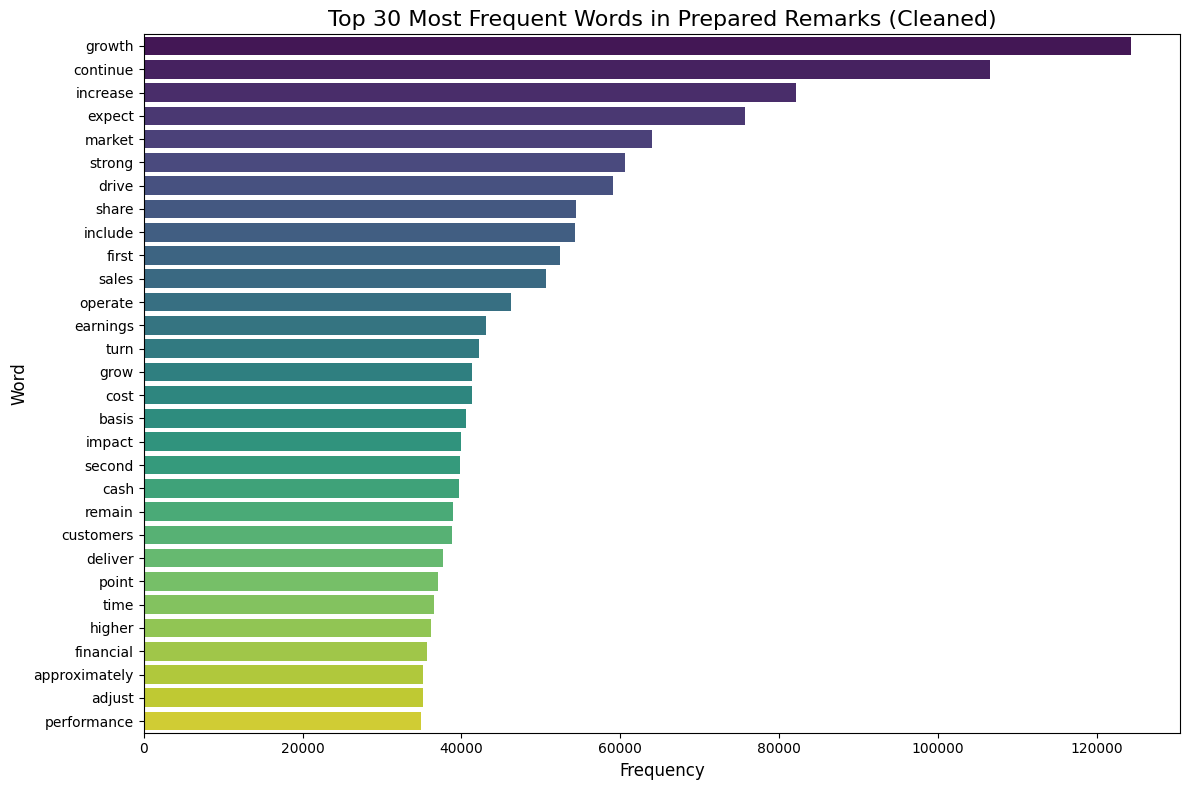

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(x='Frequency', y='Word', data=words_df, palette='viridis', ax=ax)
ax.set_title('Top 30 Most Frequent Words in Prepared Remarks (Cleaned)', fontsize=16)
ax.set_xlabel('Frequency', fontsize=12)
ax.set_ylabel('Word', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
!pip install wordcloud

### Word Cloud of Most Frequent Words in Prepared Remarks

The word cloud is another quick visual check of the cleaned prepared remarks text.

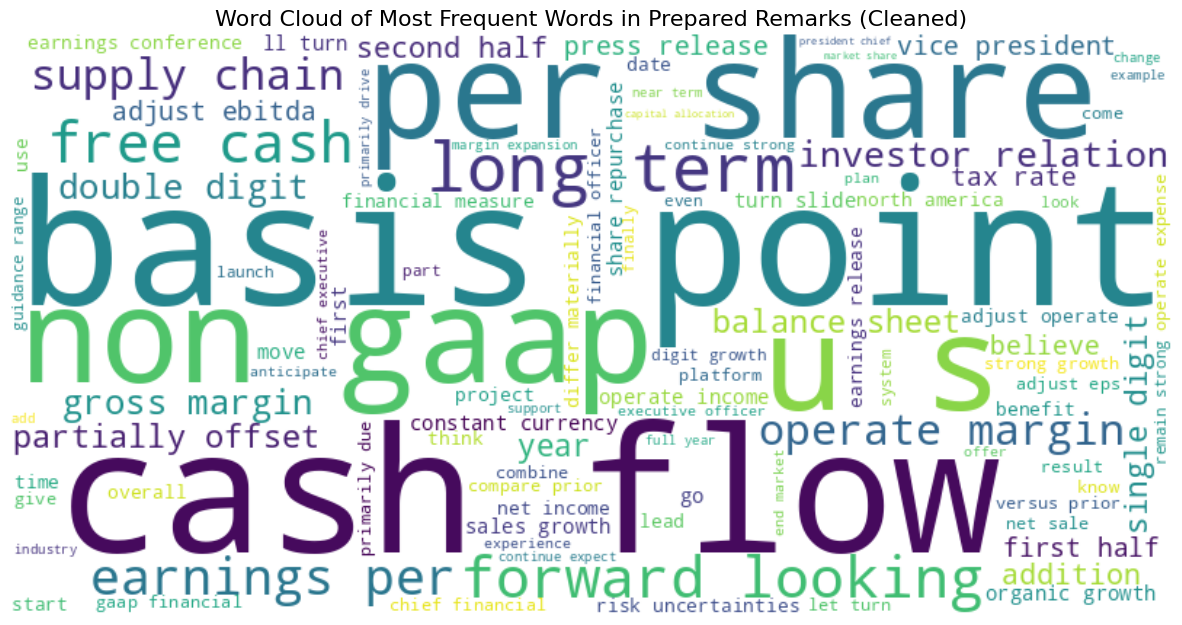

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Ensure all_prepared_remarks_text is available from previous steps
# If this cell is run independently, ensure 'pdf' is loaded and 'preprocess_text' is run.
if 'all_prepared_remarks_text' not in locals():
    print("Warning: 'all_prepared_remarks_text' not found. Re-generating from pdf.")
    all_prepared_remarks_text = ' '.join(pdf['prepared_remarks_clean'].dropna().tolist())

# Generate a word cloud image
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    colormap='viridis'
).generate(all_prepared_remarks_text)

# Display the generated image:
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Most Frequent Words in Prepared Remarks (Cleaned)', fontsize=16)
plt.show()